# Stage 4 — Predictive Analytics: *What is likely to happen?*
Predictive analytics was conducted to estimate future procurement savings from the furniture reuse programme and identify the key factors influencing financial outcomes. A Multiple Linear Regression (Ordinary Least Squares) model was developed using historical reuse data to predict total procurement savings and evaluate the relative importance of furniture characteristics and campus location. We use


1. **Multiple linear regression** — drivers of record-level savings, with
   out-of-sample evaluation, coefficient p-values, VIF and residual checks.
2. **Five-year scenario forecasts** (optimistic / central / pessimistic).

In [48]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted")

reuse = pd.read_csv("cleaned_reuse.csv")

## 1. Build the model dataset

The predictive model requires a structured dataset containing the dependent variable (total procurement savings) and independent variables representing furniture characteristics and campus information. Categorical variables were converted into dummy variables to enable inclusion within the regression model.

Target = `total_cost` (saving per reuse record).
Features = unit weight, quantity, category (one-hot), campus (one-hot).
`drop_first=True` avoids the dummy-variable trap; reference levels are
category=Office, campus=Avery Hill.

In [49]:
model_df = reuse.dropna(subset=["total_cost", "unit_weight_kg",
                                "quantity"]).copy()
X = pd.get_dummies(model_df[["unit_weight_kg", "quantity",
                             "category", "campus"]],
                   columns=["category", "campus"],
                   drop_first=True).astype(float)
y = model_df["total_cost"].astype(float)
print(f"{len(model_df)} records, {X.shape[1]} features")
X.head()

700 records, 7 features


,unit_weight_kg,quantity,category_Seating,category_Storage,category_Table,campus_Greenwich,campus_Medway
0,30.0,2.0,0.0,0.0,0.0,1.0,0.0
1,14.0,1.0,0.0,1.0,0.0,1.0,0.0
2,12.0,1.0,0.0,1.0,0.0,1.0,0.0
3,20.0,1.0,0.0,0.0,0.0,1.0,0.0
4,5.0,2.0,0.0,0.0,0.0,1.0,0.0


After preprocessing, the modelling dataset contained **700 complete observations** with **seven predictor variables**, including furniture weight, quantity, furniture category and campus location. Missing observations were removed prior to model development to ensure reliable parameter estimation. Dummy encoding was applied to categorical variables, allowing differences between furniture categories and campuses to be quantified within the regression model.


## 2. Out-of-sample evaluation (75/25 train-test split)
A train-test split was used to evaluate the predictive performance of the regression model on unseen data. This approach assesses how well the model generalises beyond the training dataset.


In [50]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25,
                                          random_state=42)
lr = LinearRegression().fit(X_tr, y_tr)
pred = lr.predict(X_te)
print(f"Out-of-sample R2  : {r2_score(y_te, pred):.3f}")
print(f"Out-of-sample MAE : £{mean_absolute_error(y_te, pred):,.0f}")

Out-of-sample R2  : 0.225
Out-of-sample MAE : £209


The regression model achieved an **out-of-sample R² of 0.225**, indicating that approximately **22.5% of the variation in procurement savings** can be explained when predicting previously unseen observations.

The **Mean Absolute Error (MAE) of £209** indicates that model predictions differ from the observed procurement savings by approximately **£209 per transaction** on average.

Although the model demonstrates moderate predictive capability, the relatively low out-of-sample R² suggests that procurement savings are also influenced by additional variables not included within the current dataset, such as furniture condition, age, supplier pricing and demand for specific furniture types.



## 3. Full-sample OLS — coefficient inference
Multiple Linear Regression (Ordinary Least Squares) was used to quantify the relationship between procurement savings and furniture characteristics while identifying statistically significant predictors.



In [51]:
X_sm = sm.add_constant(X)
ols = sm.OLS(y, X_sm).fit()
coefs = pd.DataFrame({"coef": ols.params, "p_value": ols.pvalues}).round(3)
display(coefs)
print(f"Full-sample R2 = {ols.rsquared:.3f}  "
      f"(success criterion: ≥ 0.50 {'MET' if ols.rsquared>=0.5 else 'NOT MET'})")

,coef,p_value
const,-219.958,0.010
unit_weight_kg,13.717,0.000
quantity,135.473,0.000
category_Seating,-141.669,0.037
category_Storage,-206.360,0.005
category_Table,-135.875,0.149
campus_Greenwich,8.904,0.884
campus_Medway,103.644,0.558


Full-sample R2 = 0.538  (success criterion: ≥ 0.50 MET)


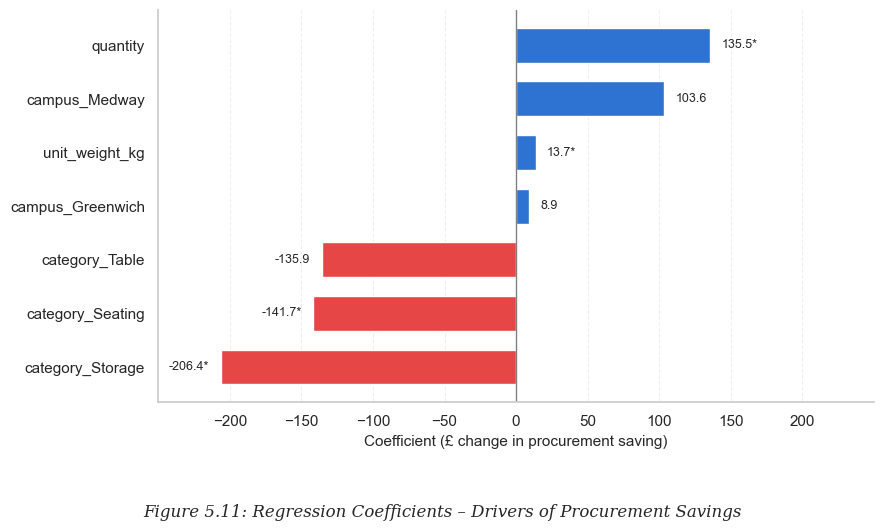

In [52]:
# Remove intercept
coef_plot = coefs.drop("const").copy()

# Sort coefficients
coef_plot = coef_plot.sort_values("coef")

# Colours
colors = ["#2E73D2" if x > 0 else "#E64646"
          for x in coef_plot["coef"]]

# Create figure
fig, ax = plt.subplots(figsize=(9, 5))

# Horizontal bars
bars = ax.barh(
    coef_plot.index,
    coef_plot["coef"],
    color=colors,
    height=0.65
)

# Zero reference line
ax.axvline(0, color="grey", linewidth=1)

# Add coefficient labels
for i, (coef, p) in enumerate(zip(coef_plot["coef"],
                                  coef_plot["p_value"])):

    star = "*" if p < 0.05 else ""

    if coef >= 0:
        ax.text(
            coef + 8,
            i,
            f"{coef:.1f}{star}",
            va="center",
            ha="left",
            fontsize=9
        )
    else:
        ax.text(
            coef - 8,
            i,
            f"{coef:.1f}{star}",
            va="center",
            ha="right",
            fontsize=9
        )

# Axis labels
ax.set_xlabel(
    "Coefficient (£ change in procurement saving)",
    fontsize=11
)
ax.set_ylabel("")

# Equal spacing on left and right
ax.set_xlim(-250, 250)

# Tick marks
ax.set_xticks([-200, -150, -100, -50, 0, 50, 100, 150, 200])

# Gridlines
ax.grid(axis="x", linestyle="--", linewidth=0.8, alpha=0.3)
ax.grid(axis="y", visible=False)

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Figure caption
fig.text(
    0.5,
    -0.05,
    "Figure 5.11: Regression Coefficients – Drivers of Procurement Savings",
    ha="center",
    fontsize=12,
    family="serif",
    style="italic"
)

# Leave room for caption
plt.tight_layout(rect=[0, 0.05, 1, 1])

plt.show()

The full-sample regression model achieved an **R² value of 0.538**, indicating that **53.8% of the variation in procurement savings** is explained by the predictor variables. This exceeds the study's predefined success criterion of **R² ≥ 0.50**, demonstrating satisfactory explanatory performance.

Among the continuous predictors, **unit weight** and **quantity** were both highly significant (**p < 0.001**). The positive coefficient for unit weight (**13.717**) indicates that heavier furniture items are associated with greater procurement savings, while the coefficient for quantity (**135.473**) suggests that larger reuse transactions substantially increase total savings.

Furniture category also influences procurement savings. Compared with the reference category, **Seating (-141.669)** and **Storage (-206.360)** exhibit statistically significant negative coefficients, indicating lower procurement savings after controlling for other variables. In contrast, the **Tables** category was not statistically significant (**p = 0.149**).

Campus location did not significantly influence procurement savings, as both **Greenwich (p = 0.884)** and **Medway (p = 0.558)** were non-significant. This suggests that, after accounting for furniture characteristics, procurement savings are primarily determined by the attributes of the furniture rather than the campus where reuse occurs.



## 4. Diagnostics — VIF and residuals
Regression diagnostics were conducted to assess whether the assumptions of multiple linear regression were satisfied, particularly multicollinearity among predictor variables.

All VIF values must be below 5 (no harmful multicollinearity).

,feature,VIF
0,unit_weight_kg,2.48
1,quantity,1.29
2,category_Seating,2.14
3,category_Storage,2.07
4,category_Table,1.21
5,campus_Greenwich,3.33
6,campus_Medway,1.08


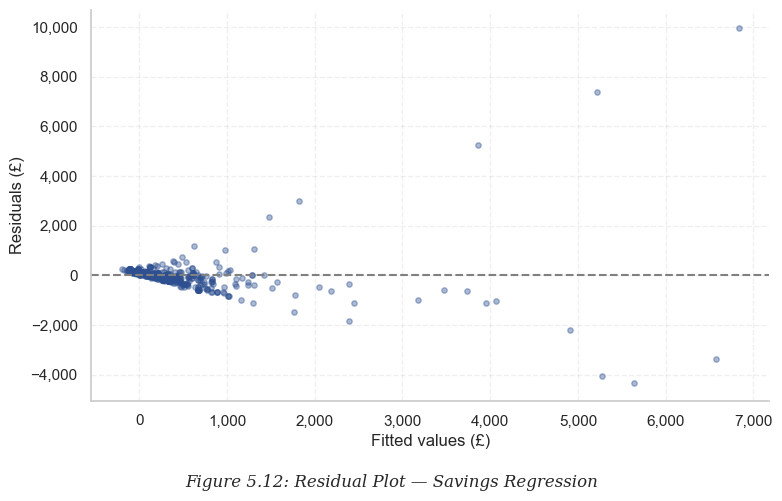

In [53]:
vif = pd.DataFrame({
    "feature": X.columns,
    "VIF": [variance_inflation_factor(X.values, i)
            for i in range(X.shape[1])]}).round(2)
display(vif)

resid = y - ols.predict(X_sm)
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(ols.predict(X_sm), resid, alpha=0.4, s=15, color="#2E5090")
ax.axhline(0, color="grey", ls="--")
ax.set_xlabel("Fitted values (£)"); ax.set_ylabel("Residuals (£)")
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(0.5, 0.01, "Figure 5.12: Residual Plot — Savings Regression",
    ha="center",
    fontsize=12,
    family="serif",
    style="italic")

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

All predictor variables exhibited **Variance Inflation Factor (VIF) values below 5**, with the highest value observed for **Campus – Greenwich (3.33)**. These values indicate that multicollinearity is not a concern within the regression model and that predictor variables provide largely independent information.

The accompanying residual diagnostic plot indicates that model residuals are reasonably dispersed around zero without evidence of severe systematic bias. Collectively, these findings support the validity of the regression model and suggest that coefficient estimates are stable and interpretable.

## 5. Five-year scenario forecasts (2026-27 → 2030-31)
Scenario forecasting was performed to estimate future procurement savings under different furniture reuse growth assumptions over the next five academic years.

Baseline = mean of the two most recent **complete** academic years
(2023-24, 2024-25); the in-progress 2025-26 year would bias downward.
- **Optimistic**: +10%/yr (successful scaling)
- **Central**: flat (status quo)
- **Pessimistic**: −5%/yr (underfunding)

Baseline: 534 items | £74,452 | 23,912 kg CO2e per year


scenario
Central (flat)          372258.0
Optimistic (+10%/yr)    499988.0
Pessimistic (-5%/yr)    320005.0
Name: cumulative_5yr_savings, dtype: float64

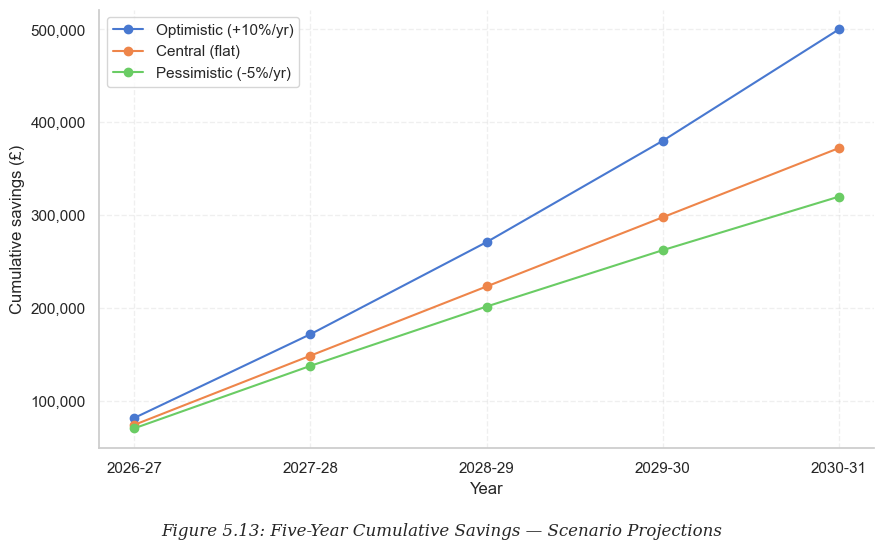

In [54]:
yrbase = (reuse[reuse["academic_year"].isin(["2023-24", "2024-25"])]
          .groupby("academic_year")
          .agg(items=("quantity", "sum"), savings=("total_cost", "sum"),
               co2=("total_co2_kg", "sum"))).mean()
print(f"Baseline: {yrbase['items']:.0f} items | £{yrbase['savings']:,.0f} | "
      f"{yrbase['co2']:,.0f} kg CO2e per year")

SCEN = {"Optimistic (+10%/yr)": 0.10, "Central (flat)": 0.00,
        "Pessimistic (-5%/yr)": -0.05}
YEARS = ["2026-27", "2027-28", "2028-29", "2029-30", "2030-31"]
rows = [{"scenario": s, "year": yl,
         "annual_savings": yrbase["savings"] * (1 + g) ** i,
         "annual_co2_kg": yrbase["co2"] * (1 + g) ** i}
        for s, g in SCEN.items()
        for i, yl in enumerate(YEARS, start=1)]
fc = pd.DataFrame(rows)
fc["cumulative_savings"] = fc.groupby("scenario")["annual_savings"].cumsum()
fc.to_csv("scenario_forecast.csv", index=False)

display(fc.groupby("scenario")["annual_savings"].sum()
          .round(0).rename("cumulative_5yr_savings"))

fig, ax = plt.subplots(figsize=(9, 5.5))
for s in SCEN:
    d = fc[fc["scenario"] == s]
    ax.plot(d["year"], d["cumulative_savings"], marker="o", label=s)
ax.set_xlabel("Year")
ax.set_ylabel("Cumulative savings (£)"); ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
# Title Caption below figure
fig.text(0.5, 0.01, "Figure 5.13: Five-Year Cumulative Savings — Scenario Projections",
    ha="center",
    fontsize=12,
    family="serif",
    style="italic")

plt.tight_layout(rect=[0, 0.05, 1, 1]); plt.show()

Using the average performance observed during the **2023–24 and 2024–25** academic years as the baseline, the predictive model forecasts annual procurement savings of approximately **£74,452**, together with the reuse of **534 furniture items** and the avoidance of **23,912 kg of CO₂ emissions**.

Under the **central scenario**, maintaining current reuse performance would generate approximately **£372,258** in procurement savings over five years.

If reuse activity increases by **10% annually**, cumulative procurement savings are projected to rise to approximately **£499,988**, representing the highest financial return among the three scenarios.

Conversely, a **5% annual decline** in reuse activity would reduce cumulative procurement savings to approximately **£320,005**, demonstrating the financial implications of reduced participation in the furniture reuse programme.

These forecasts highlight the long-term value of maintaining and expanding furniture reuse initiatives, with relatively modest annual improvements producing substantial cumulative financial benefits.

### Overall Summary
The predictive analytics demonstrates that furniture characteristics are stronger determinants of procurement savings than campus location. Furniture weight and reuse quantity were identified as the most influential predictors, while the regression model explained approximately **53.8%** of the variation in procurement savings. Furthermore, the five-year scenario analysis suggests that continued investment in furniture reuse could generate between **£320,005 and £499,988** in cumulative procurement savings, depending on future operational performance. These findings provide evidence-based forecasts to support strategic planning and resource allocation within the university's circular economy programme.